# 📓 Notebook 04 — Profiling Pós-Treinamento e Validação por Conjunto

> **Pergunta operacional:** como interrogar os splits (treino / teste / homologação) antes de aprovar o modelo?
>
> **Origem canônica:** Disciplina 01, Aula 03 (validação, diagnóstico, Model Card).

## Objetivo

Aplicar três tipos de inspeção sobre os splits **depois** que o treino terminou:

1. **Data profiling** — comparar distribuições entre treino, teste e homologação;
2. **Performance por fatia** — checar se o modelo é bom em todos os segmentos relevantes;
3. **Diagnóstico bias-variance** — curva de aprendizado e análise de erros.

## Por que isso importa

Modelo com AUC alto na média **e** ruim em um segmento crítico de negócio (ex.: clientes Two Year com alta receita) é mais perigoso do que modelo médio em tudo. Esta inspeção é o que vai virar o **Model Card** entregue na Etapa 4 do TC.

## 0. Setup e splits canônicos

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = pd.read_csv(Path("../dataset/processed/telco_churn.csv"))
df["churn_bin"] = (df["churn"] == "Yes").astype(int)

FEATURES = [
    "tenure",
    "monthly_charges",
    "total_charges",
    "contract",
    "internet_service",
    "payment_method",
    "online_security",
    "tech_support",
    "paperless_billing",
]
NUM = ["tenure", "monthly_charges", "total_charges"]
CAT = [c for c in FEATURES if c not in NUM]
TARGET = "churn_bin"

X, y = df[FEATURES], df[TARGET]

# Três conjuntos disciplinares: treino, teste, homologação.
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED)
X_test, X_holdout, y_test, y_holdout = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_SEED
)

split_sizes = pd.Series({"treino": len(X_train), "teste": len(X_test), "homologação": len(X_holdout)})
split_sizes

treino         5600
teste          1200
homologação    1200
dtype: int64

## 1. Profiling: distribuições por conjunto

Para cada feature, comparamos a distribuição em treino × teste × homologação. Diferenças grandes sinalizam que os splits não são equivalentes — o modelo pode estar prevendo um problema diferente do esperado.

In [2]:
@dataclass(slots=True)
class SplitProfile:
    column: str
    train_mean: float
    test_mean: float
    holdout_mean: float
    psi_train_vs_holdout: float


def psi(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    quantiles = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(quantiles) < 3:
        return 0.0
    exp_hist, _ = np.histogram(expected, bins=quantiles)
    act_hist, _ = np.histogram(actual, bins=quantiles)
    exp_pct = np.clip(exp_hist / exp_hist.sum(), 1e-6, None)
    act_pct = np.clip(act_hist / max(act_hist.sum(), 1), 1e-6, None)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

profiles: list[SplitProfile] = []
for col in NUM:
    profiles.append(
        SplitProfile(
            column=col,
            train_mean=float(X_train[col].mean()),
            test_mean=float(X_test[col].mean()),
            holdout_mean=float(X_holdout[col].mean()),
            psi_train_vs_holdout=psi(X_train[col].to_numpy(), X_holdout[col].to_numpy()),
        )
    )
profile_df = pd.DataFrame([asdict(p) for p in profiles]).round(3)
profile_df

,column,train_mean,test_mean,holdout_mean,psi_train_vs_holdout
0,tenure,35.639,35.896,35.716,0.012
1,monthly_charges,69.161,68.123,67.618,0.009
2,total_charges,2456.878,2447.845,2404.858,0.004


> 🔎 **Leitura.** PSI < 0.1 indica distribuição estável, 0.1–0.25 é alerta, > 0.25 é mudança severa. Em treino sintético, esperamos PSI baixo — em produção, este é o gatilho mais comum de re-treino.

## 2. Treinar o pipeline e medir nas três fatias

In [3]:
preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
    ]
)
model = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=500, random_state=RANDOM_SEED))])
model.fit(X_train, y_train)

def eval_split(name: str, X_: pd.DataFrame, y_: pd.Series) -> dict[str, float]:
    proba = model.predict_proba(X_)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "split": name,
        "auc": float(roc_auc_score(y_, proba)),
        "pr_auc": float(average_precision_score(y_, proba)),
        "f1": float(((2 * (pred == 1) * (y_ == 1)).sum()) / max(((pred == 1).sum() + (y_ == 1).sum()), 1)),
        "precision": float(((pred == 1) & (y_ == 1)).sum() / max((pred == 1).sum(), 1)),
        "recall": float(((pred == 1) & (y_ == 1)).sum() / max((y_ == 1).sum(), 1)),
    }

perf = pd.DataFrame([
    eval_split("treino", X_train, y_train),
    eval_split("teste", X_test, y_test),
    eval_split("homologação", X_holdout, y_holdout),
]).round(3)
perf

,split,auc,pr_auc,f1,precision,recall
0,treino,0.981,0.953,0.869,0.883,0.856
1,teste,0.971,0.935,0.834,0.873,0.799
2,homologação,0.977,0.949,0.862,0.890,0.836


### 🛑 Breakpoint — discussão

1. Quando a queda treino → teste é normal? Quando é overfitting?
2. Por que homologação pode ter recall pior mesmo com AUC parecida?
3. Qual delta entre teste e homologação é aceitável para promover o modelo?

## 3. Performance por fatia (slice metrics)

Mesmo com AUC global boa, segmentos importantes podem estar fora do contrato. Aqui medimos por `contract` e por `internet_service` — as duas fatias com maior impacto operacional no churn.

In [4]:
def slice_report(X_: pd.DataFrame, y_: pd.Series, slice_col: str) -> pd.DataFrame:
    proba = model.predict_proba(X_)[:, 1]
    rows = []
    for value, idx in pd.Series(X_[slice_col]).groupby(X_[slice_col]).groups.items():
        ys = y_.loc[idx]
        ps = proba[X_.index.isin(idx)]
        if len(ys.unique()) < 2:
            continue
        rows.append(
            {
                "slice": f"{slice_col}={value}",
                "n": len(ys),
                "churn_rate": round(ys.mean(), 3),
                "auc": round(float(roc_auc_score(ys, ps)), 3),
                "pr_auc": round(float(average_precision_score(ys, ps)), 3),
            }
        )
    return pd.DataFrame(rows).sort_values("auc", ascending=False)

pd.concat(
    [slice_report(X_holdout, y_holdout, "contract"), slice_report(X_holdout, y_holdout, "internet_service")],
    ignore_index=True,
)

,slice,n,churn_rate,auc,pr_auc
0,contract=Two year,265,0.015,0.996,0.875
1,contract=Month-to-month,677,0.442,0.964,0.961
2,contract=One year,258,0.058,0.940,0.501
3,internet_service=DSL,400,0.178,0.978,0.925
4,internet_service=No,271,0.214,0.978,0.929
5,internet_service=Fiber optic,529,0.357,0.973,0.961


## 4. Curva de aprendizado (bias-variance)

A curva mostra como AUC de treino e validação evoluem com o tamanho do treino. Se as curvas convergem alto, modelo está bem; se a de treino dispara longe da validação, há overfitting.

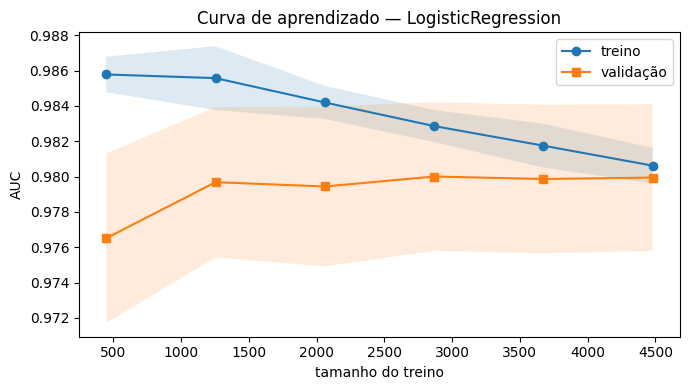

In [5]:
sizes, train_scores, valid_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=1,
    random_state=RANDOM_SEED,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, train_scores.mean(axis=1), marker="o", label="treino")
ax.plot(sizes, valid_scores.mean(axis=1), marker="s", label="validação")
ax.fill_between(sizes, train_scores.mean(axis=1) - train_scores.std(axis=1), train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
ax.fill_between(sizes, valid_scores.mean(axis=1) - valid_scores.std(axis=1), valid_scores.mean(axis=1) + valid_scores.std(axis=1), alpha=0.15)
ax.set_xlabel("tamanho do treino")
ax.set_ylabel("AUC")
ax.set_title("Curva de aprendizado — LogisticRegression")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Matriz de confusão e relatório textual

In [6]:
pred_h = (model.predict_proba(X_holdout)[:, 1] >= 0.5).astype(int)
cm = confusion_matrix(y_holdout, pred_h)
print("Confusion matrix (homologação):")
print(pd.DataFrame(cm, index=["real_não", "real_sim"], columns=["pred_não", "pred_sim"]))
print()
print(classification_report(y_holdout, pred_h, target_names=["não-churn", "churn"], digits=3))

Confusion matrix (homologação):
          pred_não  pred_sim
real_não       849        33
real_sim        52       266

              precision    recall  f1-score   support

   não-churn      0.942     0.963     0.952       882
       churn      0.890     0.836     0.862       318

    accuracy                          0.929      1200
   macro avg      0.916     0.900     0.907      1200
weighted avg      0.928     0.929     0.928      1200



## 6. Sketch de Model Card

Modelo aprovado precisa ser **documentado**. O sketch abaixo é a base do Model Card final (Etapa 4 do TC).

In [7]:
model_card = {
    "name": "telco_churn_lr_baseline_v0.1",
    "intended_use": "Pontuação diária de risco de churn (alta saliência).",
    "out_of_scope": ["PJ", "clientes em onboarding (< 30 dias)"],
    "performance": perf.set_index("split").round(3).to_dict(orient="index"),
    "slices": [
        slice_report(X_holdout, y_holdout, "contract").to_dict(orient="records"),
        slice_report(X_holdout, y_holdout, "internet_service").to_dict(orient="records"),
    ],
    "thresholds": {"churn": 0.5},
    "limitations": [
        "Dataset sintético — comportamentos reais podem divergir.",
        "PSI < 0.05 entre splits, mas alerta em produção a partir de 0.10.",
    ],
}
print("Resumo do Model Card v0.1 gerado.")

Resumo do Model Card v0.1 gerado.


## 🧠 Exercícios

**Iniciante.** Refaça `slice_report` agrupando por faixa de `tenure` (`0–12`, `13–36`, `37–72`). Qual faixa tem AUC mais baixa?

**Intermediário.** Substitua `LogisticRegression` por `GradientBoostingClassifier`. Compare matriz de confusão e PR-AUC. Qual modelo entrega menor custo de falso negativo?

**Avançado.** Implemente um `decision rule` que aplica thresholds diferentes por contrato (`Month to Month` mais sensível que `Two Year`). Avalie ganho de receita assumindo R$ 80 retidos por verdadeiro positivo e R$ 12 desperdiçados por falso positivo.

## ➡️ Próximo notebook

Modelo aprovado, próxima missão: **mantê-lo vivo em produção**. O [`05_drift_continuo_e_agentes.ipynb`](05_drift_continuo_e_agentes.ipynb) liga fluxos contínuos de drift a um agente que orquestra a resposta.